In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path 
import matplotlib.pyplot as plt 

frequency = 64
path = Path(f"data/raw/dreamt/data_{f>requency}Hz")

COLS_TO_DROP = [
    "TIMESTAMP",
    "IBI",
    "Obstructive_Apnea",
    "Central_Apnea",
    "Hypopnea",
    "Multiple_Events",
]
nb_users_max = 100
DFs= []
patient_file_list = [f for f in path.iterdir() if f.is_file()]
for patient_id in range(nb_users_max):
    patient_file = patient_file_list.pop() 
    df = pd.read_csv(patient_file)
    df["Sleep_Stage"] = df["Sleep_Stage"].replace("P", "W")
    df = df.drop(
                columns=COLS_TO_DROP
            )
    df = df[df["Sleep_Stage"] != "Missing"]
    df["patient_id"] = patient_id + 1 
    DFs.append(df)



In [4]:
whole_dataset = pd.concat(DFs, ignore_index=True)

In [ ]:
whole_dataset["Sleep_Stage"].value_counts().plot(kind="bar")
whole_dataset.groupby("patient_id").Sleep_Stage.value_counts().unstack().plot(kind="bar")

<Figure size 2000x600 with 0 Axes>

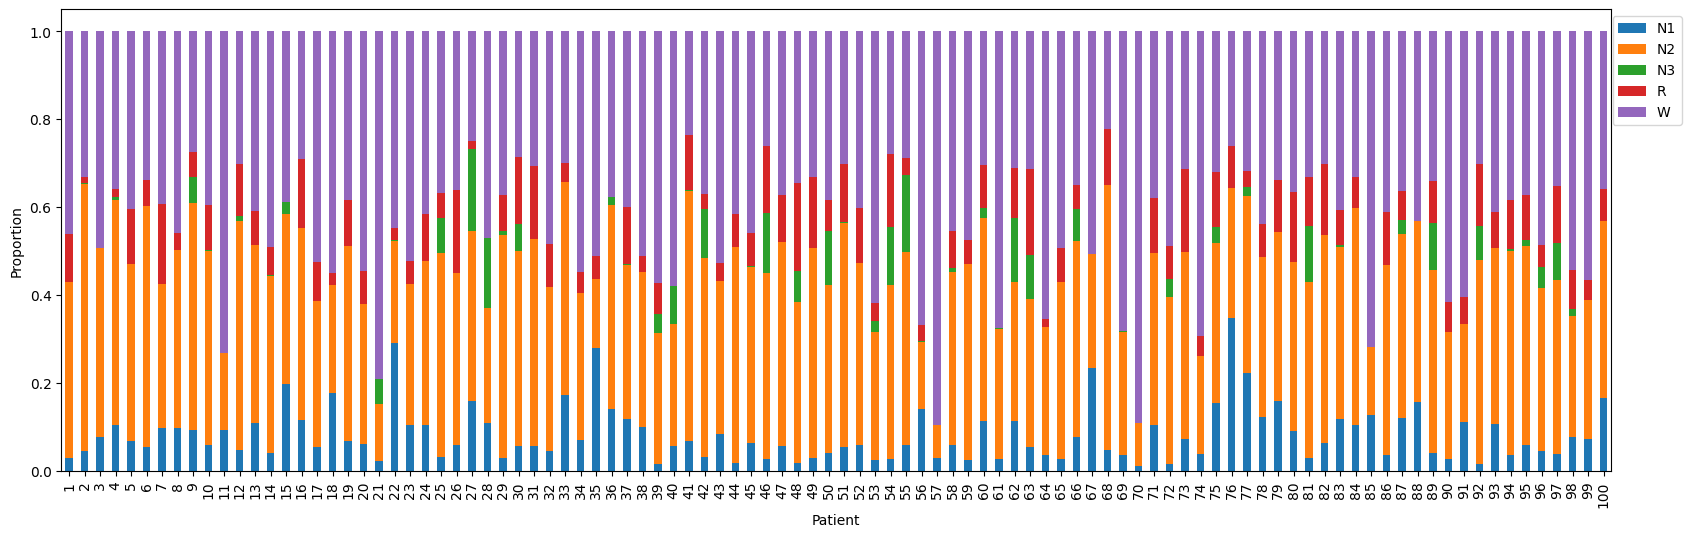

In [5]:
# proportion of each sleep stage per patient
stage_dist = (whole_dataset.groupby("patient_id")["Sleep_Stage"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0))

plt.figure(figsize=(20, 6))
stage_dist.plot(kind="bar", stacked=True, figsize=(20, 6))
plt.xlabel("Patient")
plt.ylabel("Proportion")
plt.legend(bbox_to_anchor=(1.05, 1))

Text(120.72222222222221, 0.5, 'Sleep stage')

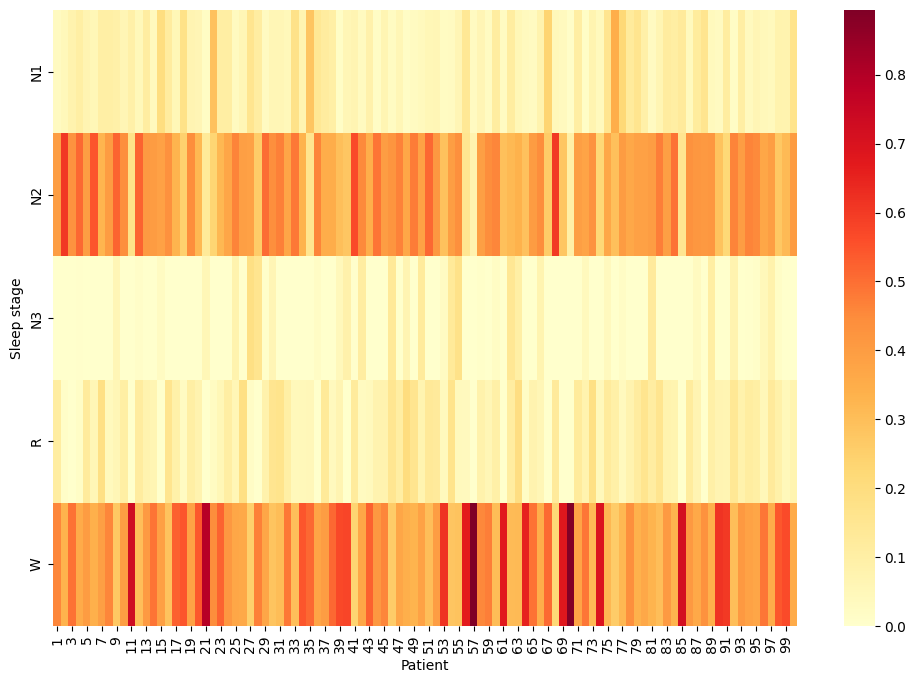

In [8]:
import seaborn as sns 

plt.figure(figsize=(12, 8))
sns.heatmap(stage_dist.T, cmap="YlOrRd", annot=False)
plt.xlabel("Patient")
plt.ylabel("Sleep stage")

Text(0, 0.5, 'EMD from global distribution')

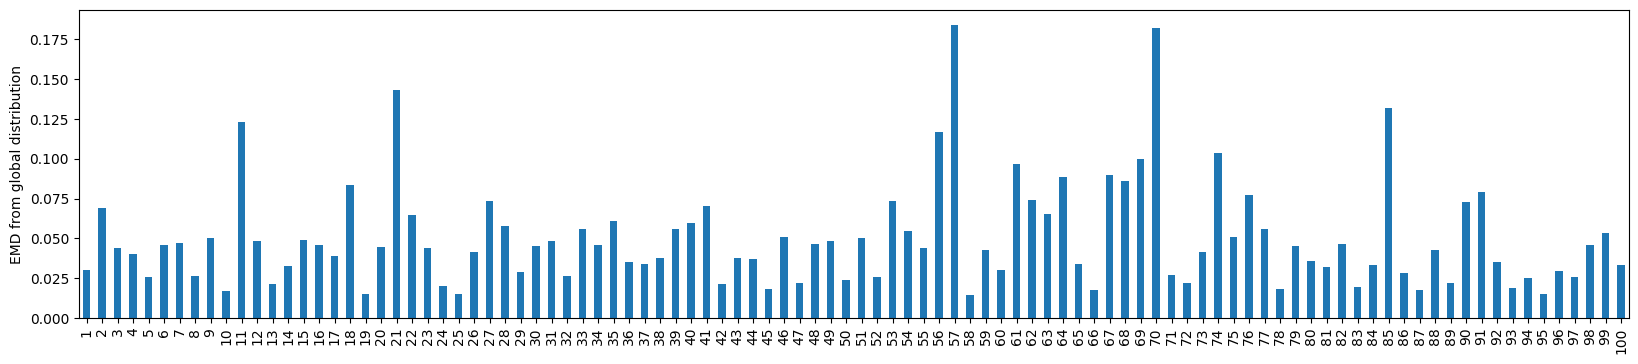

In [9]:
from scipy.stats import wasserstein_distance

global_dist = whole_dataset["Sleep_Stage"].value_counts(normalize=True)
emd_per_patient = {}
for pid, group in whole_dataset.groupby("patient_id"):
    local_dist = group["Sleep_Stage"].value_counts(normalize=True).reindex(global_dist.index, fill_value=0)
    emd_per_patient[pid] = wasserstein_distance(global_dist.values, local_dist.values)

pd.Series(emd_per_patient).plot(kind="bar", figsize=(20, 4))
plt.ylabel("EMD from global distribution")

Explained variance: 0.25


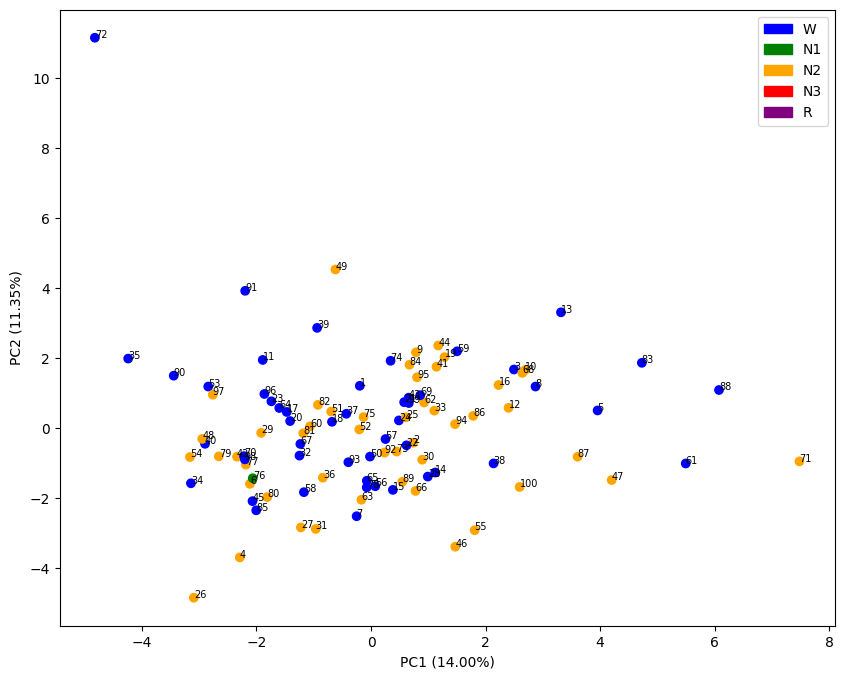

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

feature_cols = ["BVP", "EDA", "TEMP", "ACC_X", "ACC_Y", "ACC_Z", "HR"]
agg_funcs = ["mean", "std", "min", "max", "median"]
patient_features = whole_dataset.groupby("patient_id")[feature_cols].agg(agg_funcs)
patient_features.columns = ["_".join(col) for col in patient_features.columns]

scaler = StandardScaler()
X_pca = scaler.fit_transform(patient_features)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_pca)
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.2f}")
# plt.scatter(coords[:, 0], coords[:, 1])
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

dominant_stage = whole_dataset.groupby("patient_id")["Sleep_Stage"].agg(
    lambda x: x.value_counts().index[0]
)

stage_colors = {"W": "blue", "N1": "green", "N2": "orange", "N3": "red", "R": "purple"}
colors = [stage_colors[dominant_stage[pid]] for pid in patient_features.index]

plt.figure(figsize=(10, 8))
plt.scatter(coords[:, 0], coords[:, 1], c=colors)

for i, pid in enumerate(patient_features.index):
    plt.annotate(pid, (coords[i, 0], coords[i, 1]), fontsize=7)

patches = [mpatches.Patch(color=c, label=s) for s, c in stage_colors.items()]
plt.legend(handles=patches)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
plt.show()